In [4]:
import pandas as pd
import numpy as np

In [5]:
data= pd.read_csv(r"C:\Users\acer\Desktop\data science projects\Heart Diseases\dataset\diabetes.csv")
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Data inspection

In [6]:
data.shape

(768, 9)

In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [8]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [9]:
data.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [10]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

### EDA

In [11]:
numeric_col=data.select_dtypes(include=['int64','float64']).columns

binary_col=['Outcome']
numeric_col=numeric_col.drop(binary_col)
print(f"Numerical features:{numeric_col}")
print(f"Binary features:{binary_col}")

Numerical features:Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='str')
Binary features:['Outcome']


In [12]:
data[numeric_col].skew()

Pregnancies                 0.901674
Glucose                     0.173754
BloodPressure              -1.843608
SkinThickness               0.109372
Insulin                     2.272251
BMI                        -0.428982
DiabetesPedigreeFunction    1.919911
Age                         1.129597
dtype: float64

In [13]:
data[numeric_col].kurt()

Pregnancies                 0.159220
Glucose                     0.640780
BloodPressure               5.180157
SkinThickness              -0.520072
Insulin                     7.214260
BMI                         3.290443
DiabetesPedigreeFunction    5.594954
Age                         0.643159
dtype: float64

### Univariate Analysis

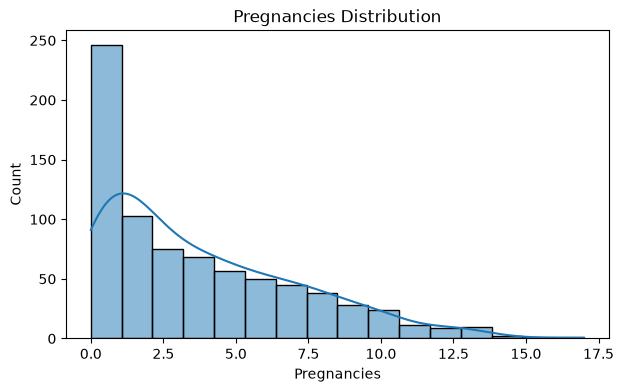

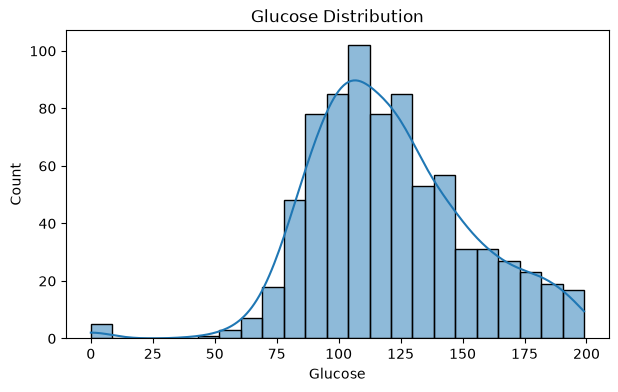

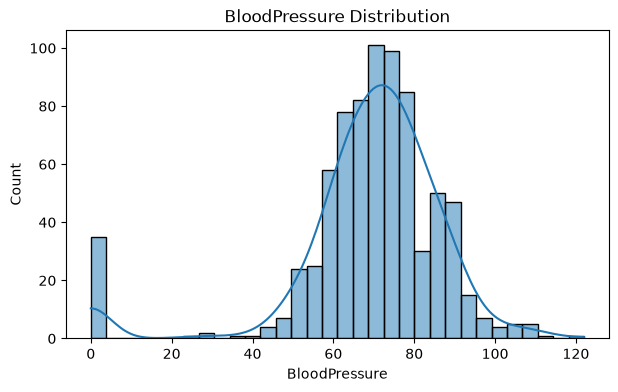

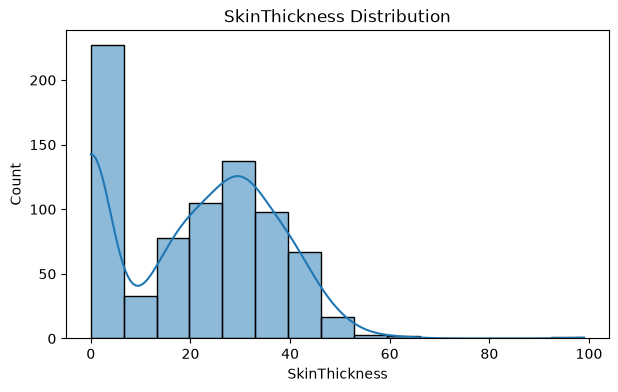

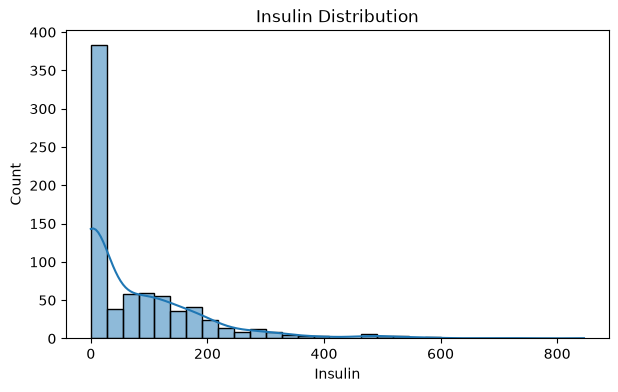

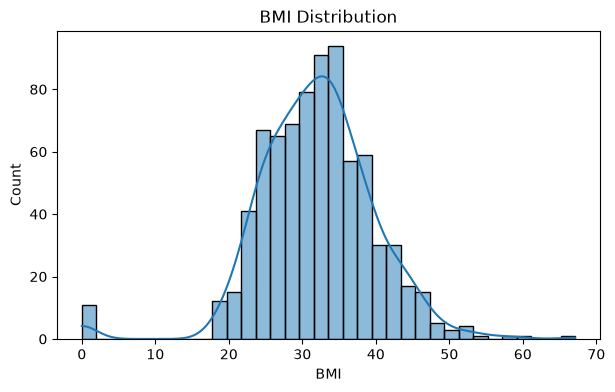

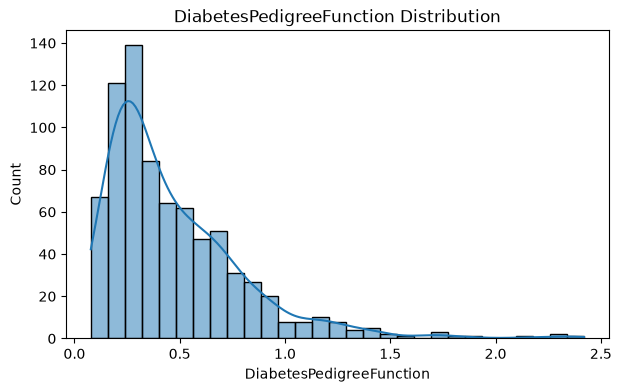

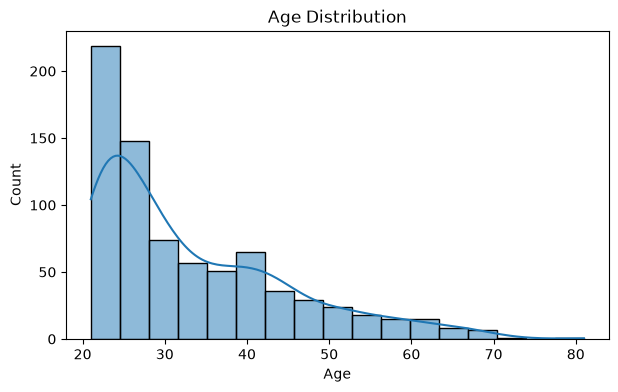

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in numeric_col:
    plt.figure(figsize=(7, 4))
    sns.histplot(data[col], kde=True)
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

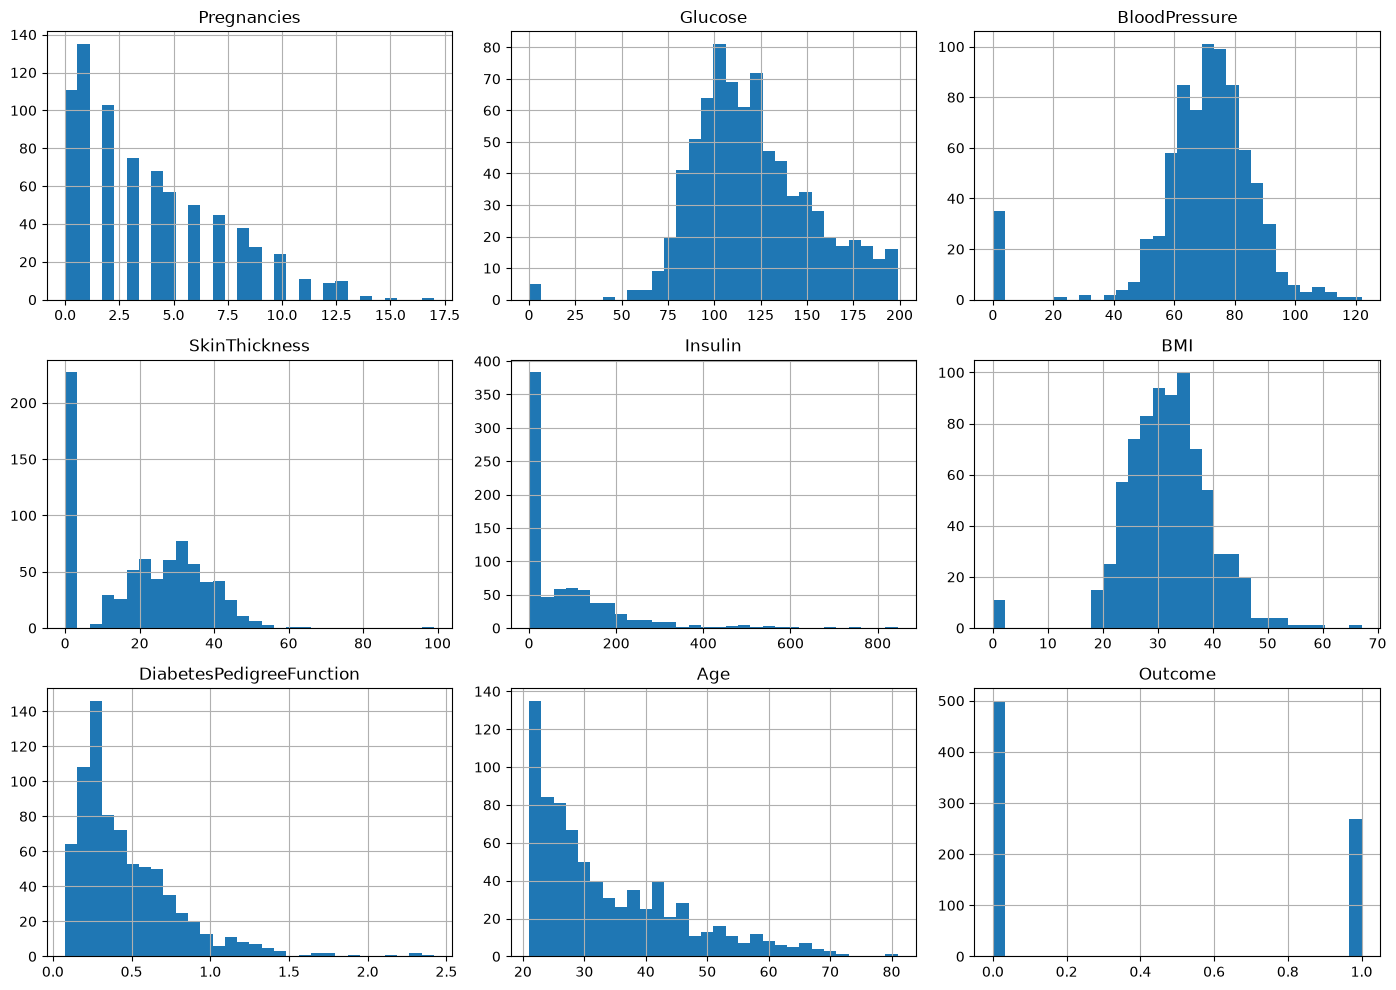

In [15]:
data.hist(
    bins=30,
    figsize=(14, 10),
    grid=True
)

plt.tight_layout()
plt.show()

what we got from this histogram our dataset has zero null values/missing values but from this histogram we can clearly see most of the null values is written as 0

Pregnacies=Most women have 0–3 pregnancies only few have 10+  this is right skewed 

glucose= Most glucose values lie between 80 and 140.  there are few null values written as 0 in medical glucose 0 is not possible 

bloodpressure= Most blood pressure values are around 60–90 mmHg as here blood pressure 0 is not possible in medically 

skin thickness= in this dataset many has 0 skin thickness which is also not possible this r the null values

insulin= same here 0 insulin is not possible in medically 

BMI = Most BMI values are between 25 and 40. There are a few 0 values, which is also not possible in medical term 

DiabetesPedigreeFunction= we can see most value are less than 1 

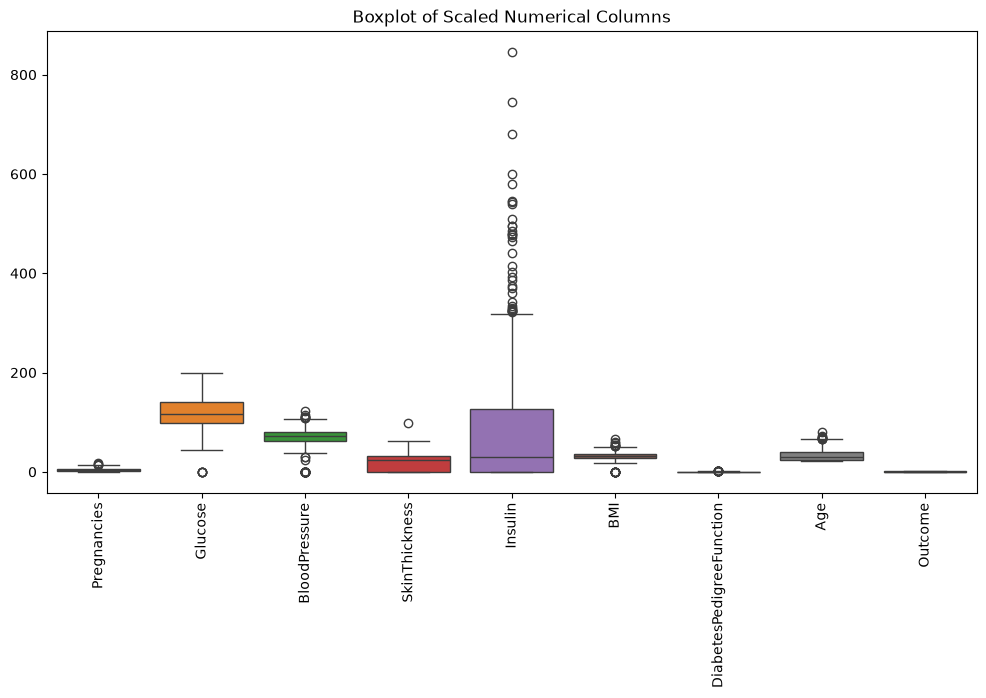

In [16]:
plt.figure(figsize=(12,6))
sns.boxplot(data=data)
plt.title('Boxplot of Scaled Numerical Columns')
plt.xticks(rotation=90)
plt.show()

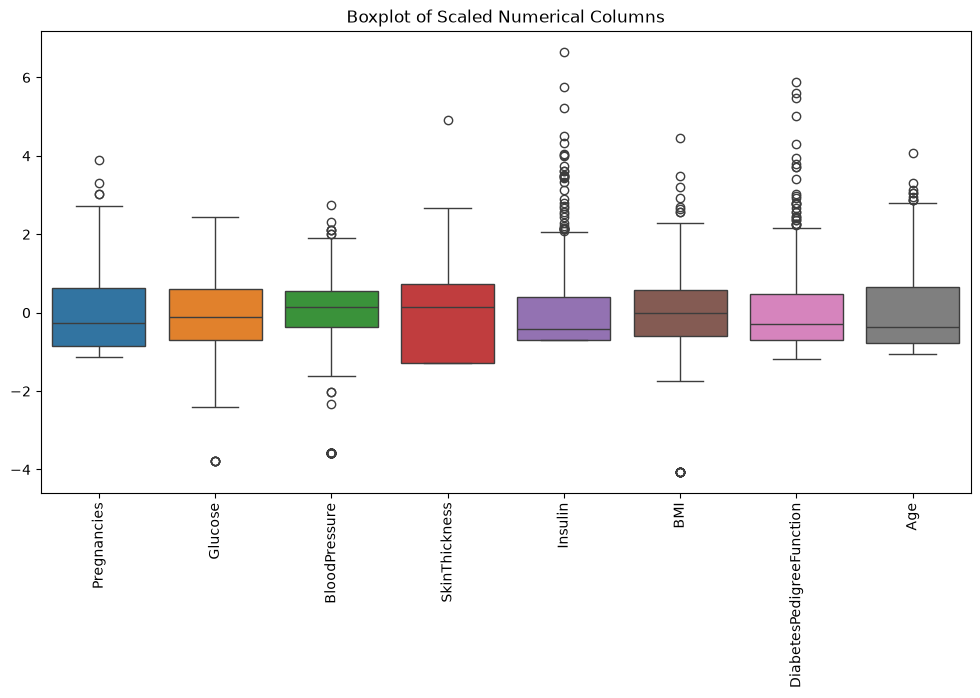

In [17]:
#boxplot 
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
scaled=scaler.fit_transform(data[numeric_col])
data_clean_scaled=pd.DataFrame(scaled,columns=numeric_col)

plt.figure(figsize=(12,6))
sns.boxplot(data=data_clean_scaled)
plt.title('Boxplot of Scaled Numerical Columns')
plt.xticks(rotation=90)
plt.show()

The boxplots indicate that several numerical features contain outliers. Among all variables, Insulin has the highest number of extreme values, followed by DiabetesPedigreeFunction and Age. Features such as Pregnancies, BloodPressure, SkinThickness, BMI, and Glucose also contain a small number of outliers. These observations suggest that outlier handling or robust modeling techniques may be considered before training machine learning models.

In [18]:
total_outliers = []

for col in numeric_col:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[col] < lower_bound) |
        (data[col] > upper_bound)
    ]

    total_outliers.append({
        'Feature': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower_Bound': lower_bound,
        'Upper_Bound': upper_bound,
        'Outlier_Count': outliers.shape[0]
    })

iqr_data = pd.DataFrame(total_outliers)

iqr_data

,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count
0,Pregnancies,1.00000,6.00000,5.0000,-6.500,13.500,4
1,Glucose,99.00000,140.25000,41.2500,37.125,202.125,5
2,BloodPressure,62.00000,80.00000,18.0000,35.000,107.000,45
3,SkinThickness,0.00000,32.00000,32.0000,-48.000,80.000,1
4,Insulin,0.00000,127.25000,127.2500,-190.875,318.125,34
5,BMI,27.30000,36.60000,9.3000,13.350,50.550,19
6,DiabetesPedigreeFunction,0.24375,0.62625,0.3825,-0.330,1.200,29
7,Age,24.00000,41.00000,17.0000,-1.500,66.500,9


In [19]:
null_value_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
data[null_value_cols] = data[null_value_cols].replace(0, np.nan)
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [20]:
data.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

### Bivariate and Multivariate Analysis

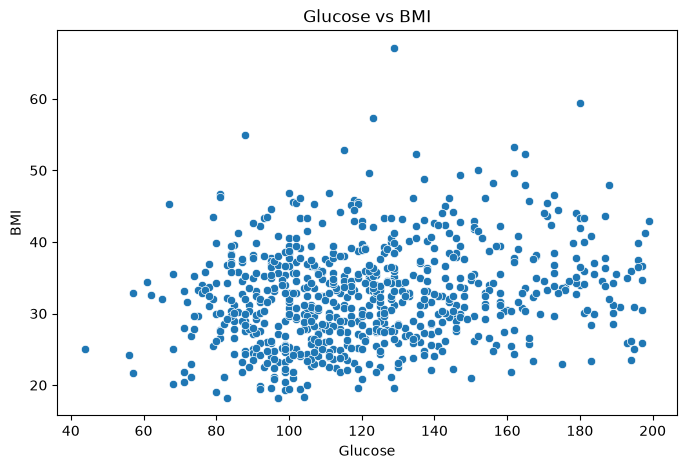

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(
    data=data,
    x="Glucose",
    y="BMI",
    ax=ax
)

ax.set_title("Glucose vs BMI")
ax.set_xlabel("Glucose")
ax.set_ylabel("BMI")

plt.show()

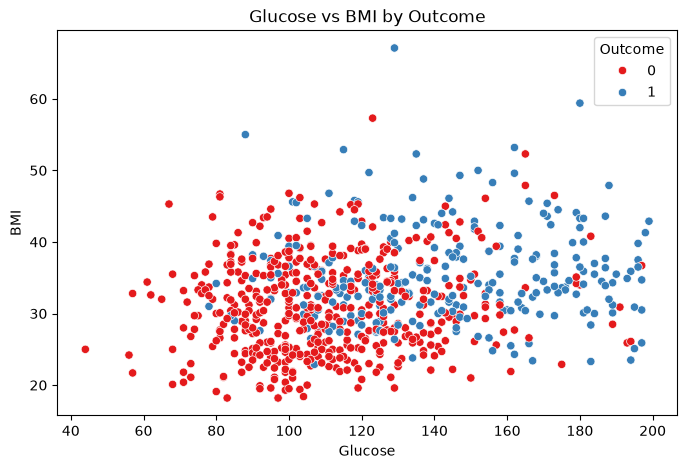

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(
    data=data,
    x="Glucose",
    y="BMI",
    hue="Outcome",
    palette="Set1",
    ax=ax
)

ax.set_title("Glucose vs BMI by Outcome")
ax.set_xlabel("Glucose")
ax.set_ylabel("BMI")

plt.show()

In [23]:
numeric_col

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='str')

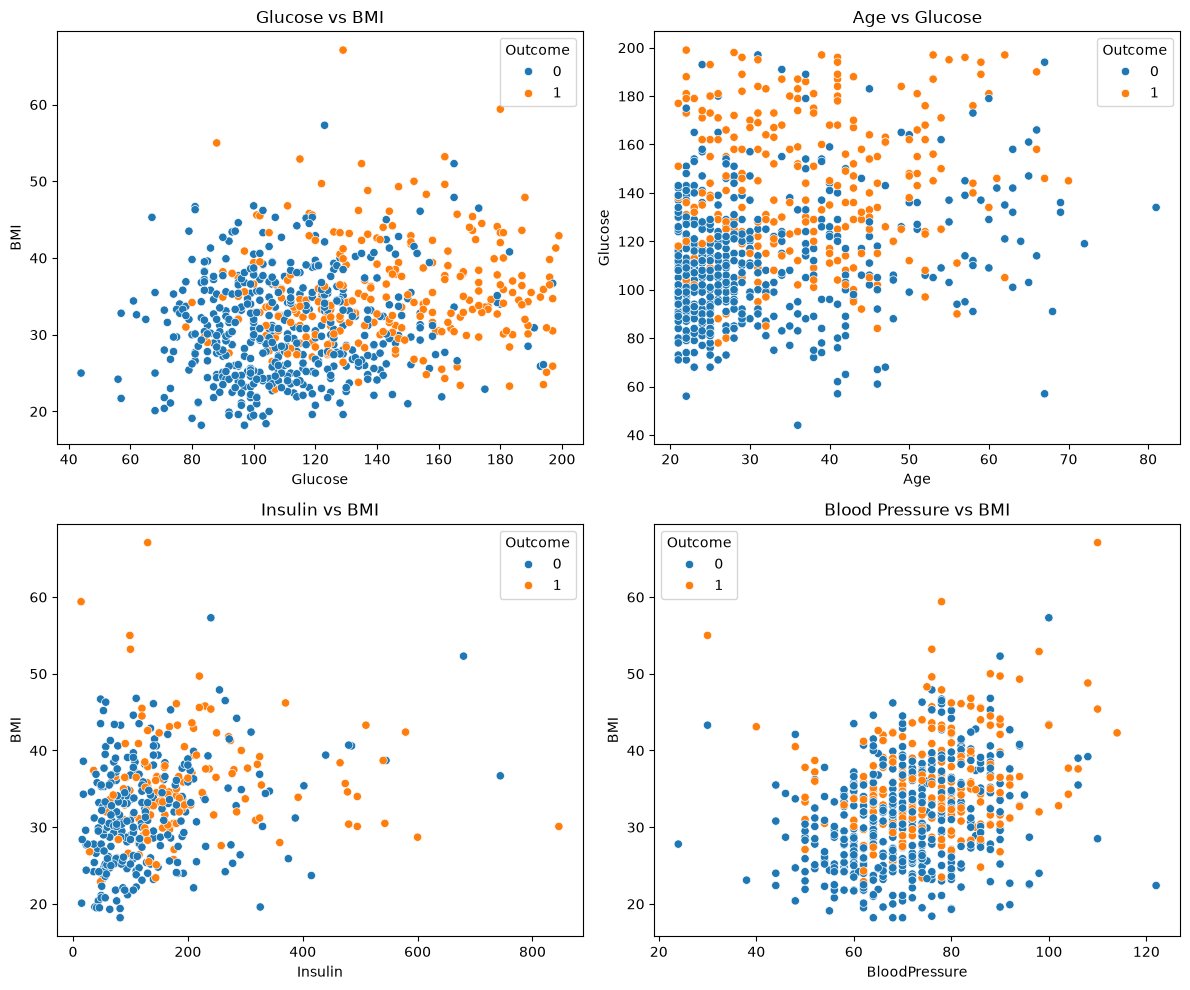

In [24]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

sns.scatterplot(data=data, x="Glucose", y="BMI", hue="Outcome", ax=axs[0, 0])
axs[0, 0].set_title("Glucose vs BMI")

sns.scatterplot(data=data, x="Age", y="Glucose", hue="Outcome", ax=axs[0, 1])
axs[0, 1].set_title("Age vs Glucose")

sns.scatterplot(data=data, x="Insulin", y="BMI", hue="Outcome", ax=axs[1, 0])
axs[1, 0].set_title("Insulin vs BMI")

sns.scatterplot(data=data, x="BloodPressure", y="BMI", hue="Outcome", ax=axs[1, 1])
axs[1, 1].set_title("Blood Pressure vs BMI")

plt.tight_layout()
plt.show()

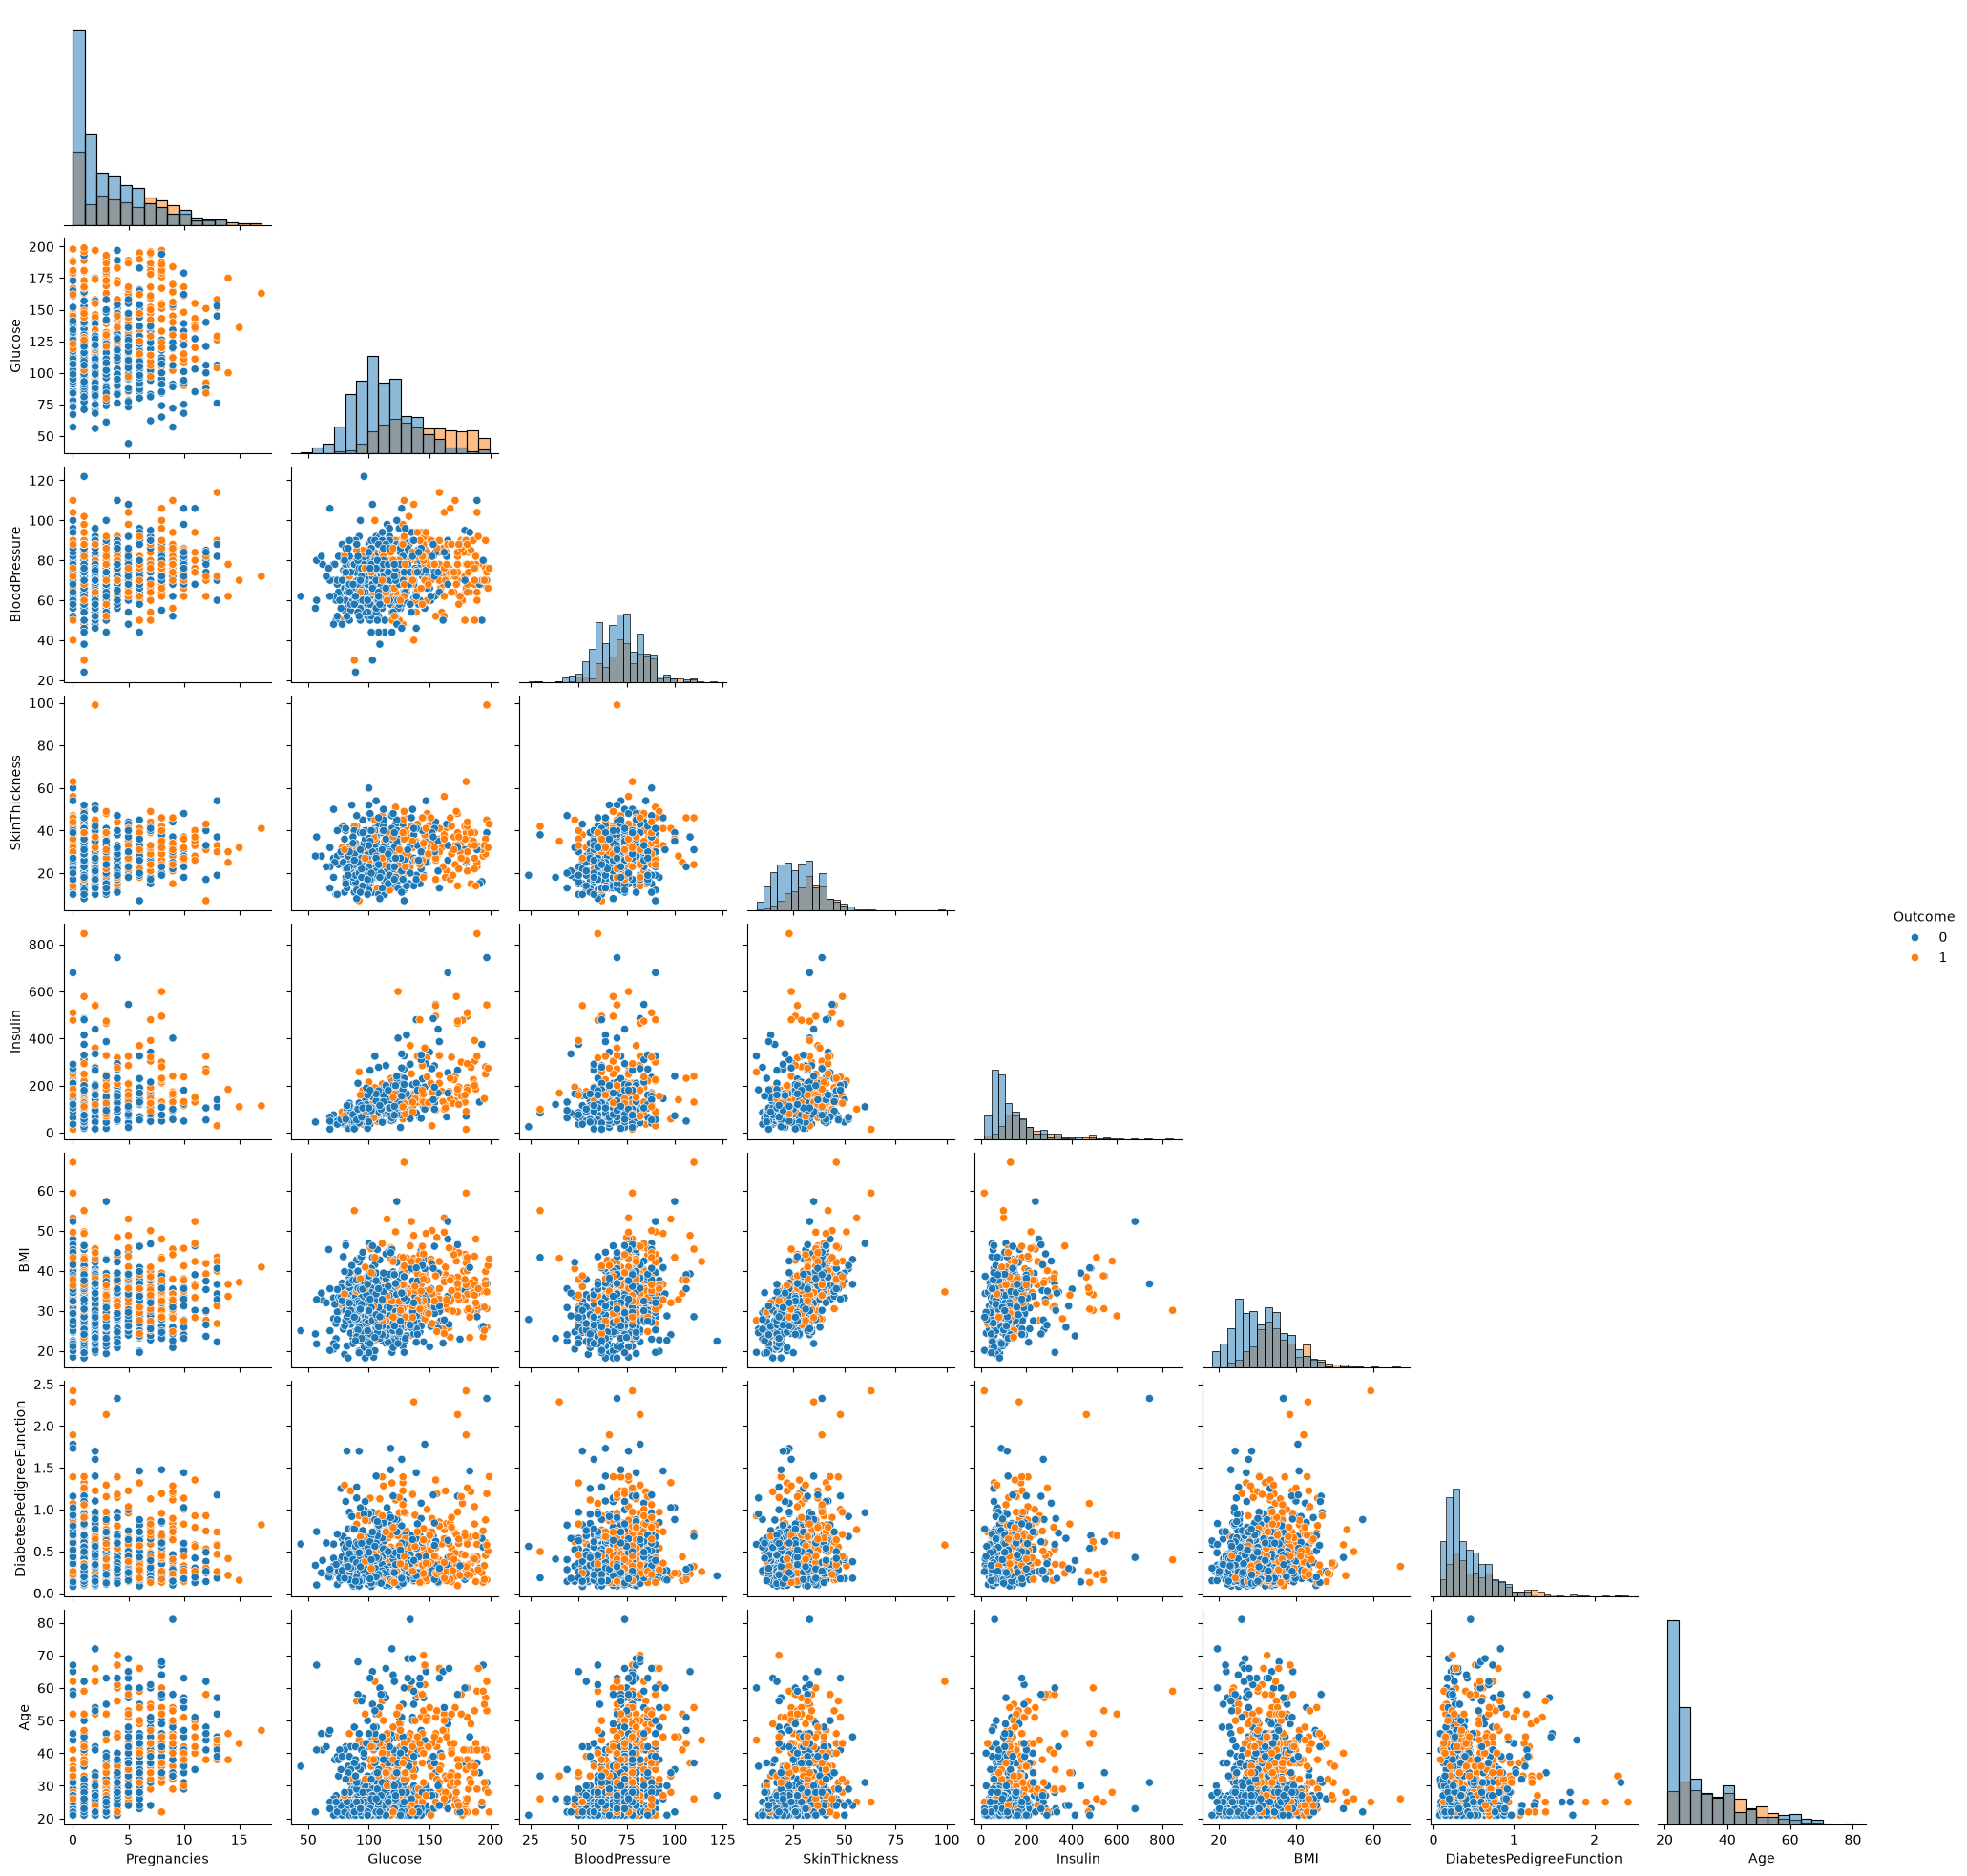

In [25]:
sns.pairplot(
    data,
    hue="Outcome",
    diag_kind="hist",
    corner=True
)

plt.show()

<Axes: >

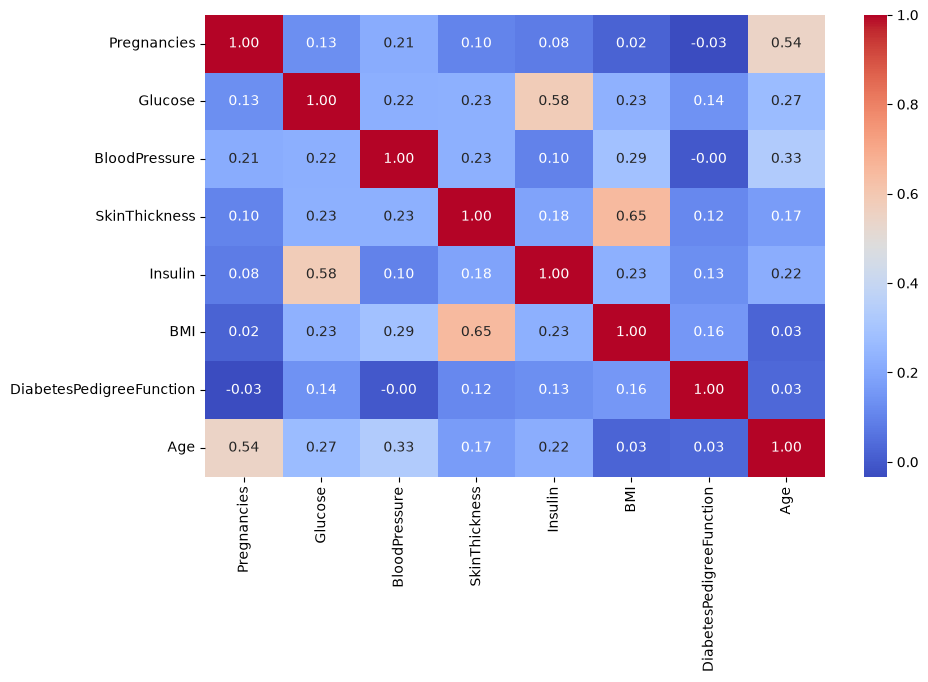

In [26]:
plt.figure(figsize=(10, 6))

corr_matrix = data[numeric_col].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

In [27]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


### Target Encoding 

In [28]:
target_encoded='Outcome'
numerical_cols=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']
print(numerical_cols)
print(target_encoded)

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Outcome


In [29]:
data['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

### Define X ,y 

In [30]:
X=data[numerical_cols]
y=data[target_encoded]


In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

In [32]:
X.value_counts()

Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin  BMI   DiabetesPedigreeFunction  Age
1            89.0     66.0           23.0           94.0     28.1  0.167                     21     1
0            137.0    40.0           35.0           168.0    43.1  2.288                     33     1
3            78.0     50.0           32.0           88.0     31.0  0.248                     26     1
2            197.0    70.0           45.0           543.0    30.5  0.158                     53     1
1            189.0    60.0           23.0           846.0    30.1  0.398                     59     1
                                                                                                   ..
0            181.0    88.0           44.0           510.0    43.3  0.222                     26     1
1            128.0    88.0           39.0           110.0    36.5  1.057                     37     1
2            88.0     58.0           26.0           16.0     28.4  0.766               

In [33]:
X_train.dtypes

Pregnancies                   int64
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
dtype: object

In [34]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols)
    ]
)

checked = preprocessor.fit_transform(X_train)
print(pd.DataFrame(checked, columns=numerical_cols).isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64


In [35]:
data.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [36]:
from scipy.stats import ttest_ind
import pandas as pd
import numpy as np

results = []

for col in numerical_cols:
    diabetic = data[data[target_encoded] == 1][col].dropna()
    non_diabetic = data[data[target_encoded] == 0][col].dropna()

    t_stat, p_value = ttest_ind(diabetic, non_diabetic, equal_var=False)

    cohen_d = (diabetic.mean() - non_diabetic.mean()) / np.sqrt(
        (diabetic.std()**2 + non_diabetic.std()**2) / 2
    )

    results.append({
        "Feature": col,
        "t_statistic": t_stat,
        "p_value": p_value,
        "Cohens_d": cohen_d,
        "Result": "Significant" if p_value < 0.05 else "Not Significant"
    })

ttest_results_df = pd.DataFrame(results).sort_values("p_value")

ttest_results_df

,Feature,t_statistic,p_value,Cohens_d,Result
1,Glucose,14.884412,2.843926e-41,1.160504,Significant
5,BMI,9.055004,2.483571e-18,0.690217,Significant
7,Age,6.920738,1.201513e-11,0.519030,Significant
3,SkinThickness,6.176587,1.825527e-09,0.566364,Significant
0,Pregnancies,5.906961,6.821926e-09,0.461277,Significant
4,Insulin,5.783322,2.672116e-08,0.645747,Significant
2,BloodPressure,4.664265,3.971545e-06,0.363354,Significant
6,DiabetesPedigreeFunction,4.576812,6.100481e-06,0.357600,Significant


### Model Selection

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_sample_weight

models = {
    'LogisticRegression': LogisticRegression( max_iter=1000, class_weight='balanced'),
    'RandomForest': RandomForestClassifier( n_estimators=200, random_state=42, class_weight='balanced'),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=200 , random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=200,random_state=42),
    'SVC': SVC( probability=True, class_weight='balanced', random_state=42)
}



cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    'accuracy': 'accuracy', 
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'recall': 'recall',
    'precision': 'precision',
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision'
}

cv_results = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])


    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,    
        n_jobs=-1,
    
    )

    cv_results.append({
        'Model': name,
        'Accuracy': scores['test_accuracy'].mean(),
        'Balanced_Accuracy': scores['test_balanced_accuracy'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall': scores['test_recall'].mean(),
        'F1_Score': scores['test_f1'].mean(),
        'ROC_AUC': scores['test_roc_auc'].mean(),
        'PR_AUC': scores['test_pr_auc'].mean()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(
    by='ROC_AUC',
    ascending=False
)

cv_results_df

,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1_Score,ROC_AUC,PR_AUC
0,LogisticRegression,0.762202,0.747998,0.648607,0.700997,0.672385,0.844381,0.747682
4,SVC,0.760536,0.760842,0.637195,0.761683,0.690163,0.837141,0.708778
1,RandomForest,0.758950,0.742161,0.646898,0.686822,0.665629,0.821044,0.700488
3,AdaBoost,0.770359,0.730309,0.702295,0.598117,0.644846,0.818884,0.696204
2,GradientBoosting,0.750766,0.710840,0.667911,0.579181,0.617924,0.814575,0.715159


### Hyperparameter Tuning with GridSeachCV

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import pandas as pd

param_grids = {
    'LogisticRegression': [
        # L1 Regularization
        {
            'classifier__penalty': ['l1'],
            'classifier__solver': ['liblinear'],
            'classifier__C': [0.01, 0.1, 1, 10]
        },


        # L2 Regularization
        {
            'classifier__penalty': ['l2'],
            'classifier__solver': ['lbfgs'],
            'classifier__C': [0.01, 0.1, 1, 10]
        },

        # Elastic Net Regularization
        {
            'classifier__penalty': ['elasticnet'],
            'classifier__solver': ['saga'],
            'classifier__C': [0.01, 0.1, 1, 10],
            'classifier__l1_ratio': [0.2, 0.5, 0.8]
        }
    ],

    'RandomForest': {
        'classifier__n_estimators': [100, 200, 300],
        'classifier__max_depth': [None, 5, 10]
    },

    'GradientBoosting': {
        'classifier__n_estimators': [100, 200],
        'classifier__learning_rate': [0.05, 0.1],
        'classifier__max_depth': [2, 3]
    },

    'AdaBoost': {
        'classifier__n_estimators': [100, 200, 300],
        'classifier__learning_rate': [0.5, 1.0]
    },

    'SVC': {
        'classifier__C': [0.1, 1, 10],
        'classifier__kernel': ['linear', 'rbf']
    }
}

tuned_results = []
best_models = {}

for name, model in models.items():

    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grids[name],
        cv=cv,
        scoring='average_precision',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    tuned_results.append({
        'Model': name,
        'Best_Params': grid.best_params_,
        'Best_PR_AUC': grid.best_score_
    })

    best_models[name] = grid.best_estimator_

tuned_results_df = pd.DataFrame(tuned_results).sort_values(
    by='Best_PR_AUC',
    ascending=False
)

tuned_results_df

c:\Users\acer\Desktop\data science projects\Heart Diseases\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\acer\Desktop\data science projects\Heart Diseases\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\acer\Desktop\data science projects\Heart Diseases\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(S

,Model,Best_Params,Best_PR_AUC
0,LogisticRegression,"{'classifier__C': 0.1, 'classifier__penalty': ...",0.751722
4,SVC,"{'classifier__C': 1, 'classifier__kernel': 'li...",0.742220
1,RandomForest,"{'classifier__max_depth': 5, 'classifier__n_es...",0.734095
2,GradientBoosting,"{'classifier__learning_rate': 0.05, 'classifie...",0.730724
3,AdaBoost,"{'classifier__learning_rate': 0.5, 'classifier...",0.709755


In [39]:
best_model = best_models[tuned_results_df.iloc[0]['Model']]

print("Best Model:", tuned_results_df.iloc[0]['Model'])
print("Best Parameters:", tuned_results_df.iloc[0]['Best_Params'])

Best Model: LogisticRegression
Best Parameters: {'classifier__C': 0.1, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}


In [40]:
from sklearn.metrics import log_loss
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
    )

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred):.3f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.3f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob):.3f}")
print(f"PR AUC   : {average_precision_score(y_test, y_prob):.3f}")



Accuracy: 0.7273
Precision: 0.591
Recall   : 0.722
F1 Score : 0.650
ROC AUC  : 0.808
PR AUC   : 0.659


In [41]:
loss = log_loss(y_test, y_prob)

print("Binary Cross Entropy:", loss)

Binary Cross Entropy: 0.5538960230459077


Binary Cross-Entropy (Log Loss) measures how well the predicted probabilities match the true labels.

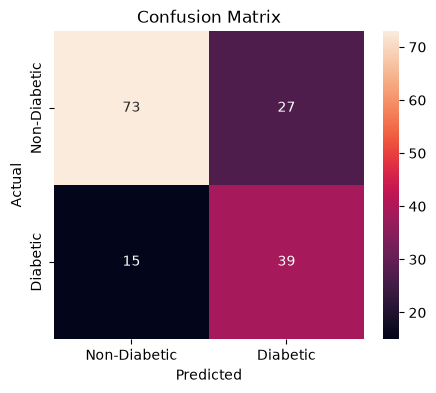

In [43]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Non-Diabetic', 'Diabetic'],
    yticklabels=['Non-Diabetic', 'Diabetic']
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

73  = Correctly predicted Non-Diabetic

27 = Actual Non-Diabetic but predicted Diabetic

15  = Actual Diabetic but predicted Non-Diabetic

39 = Correctly predicted Diabetic

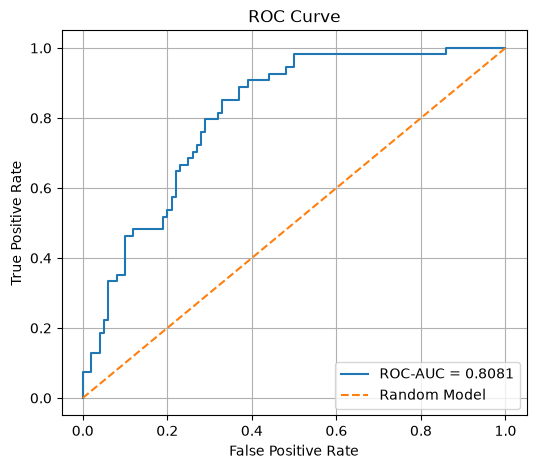

In [44]:
from sklearn.metrics import roc_curve, roc_auc_score

# Predicted probability for class 1 = Diabetic
y_proba = best_model.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# ROC-AUC score
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Model')

plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid()
plt.show()

In [45]:
best_model.predict_proba(X_test).shape

(154, 2)

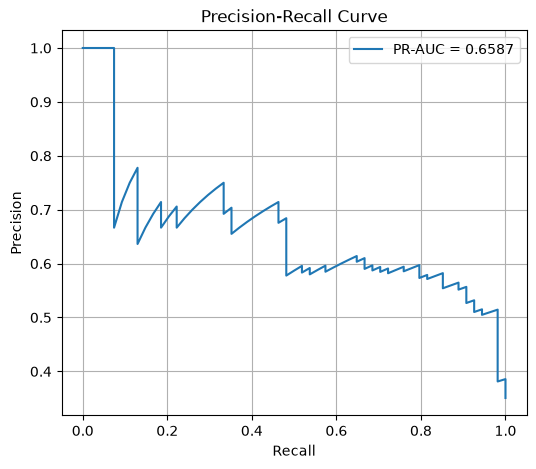

In [46]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Predicted probability for class 1 = Diabetic
y_proba = best_model.predict_proba(X_test)[:, 1]

### because precison and recall curve only use positive value (1) that why we slice the predict_prob(X_test)
# and give only vaues of positive 1 where we take all the row [:,1] ony positive

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)


pr_auc = average_precision_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'PR-AUC = {pr_auc:.4f}')

plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.grid()
plt.show()

In [47]:
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

importances = best_model.named_steps['classifier'].coef_[0]

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance_df.head(12)

,Feature,Importance
1,num__Glucose,1.043014
5,num__BMI,0.572881
0,num__Pregnancies,0.276875
6,num__DiabetesPedigreeFunction,0.176914
7,num__Age,0.123720
2,num__BloodPressure,0.000000
3,num__SkinThickness,0.000000
4,num__Insulin,0.000000


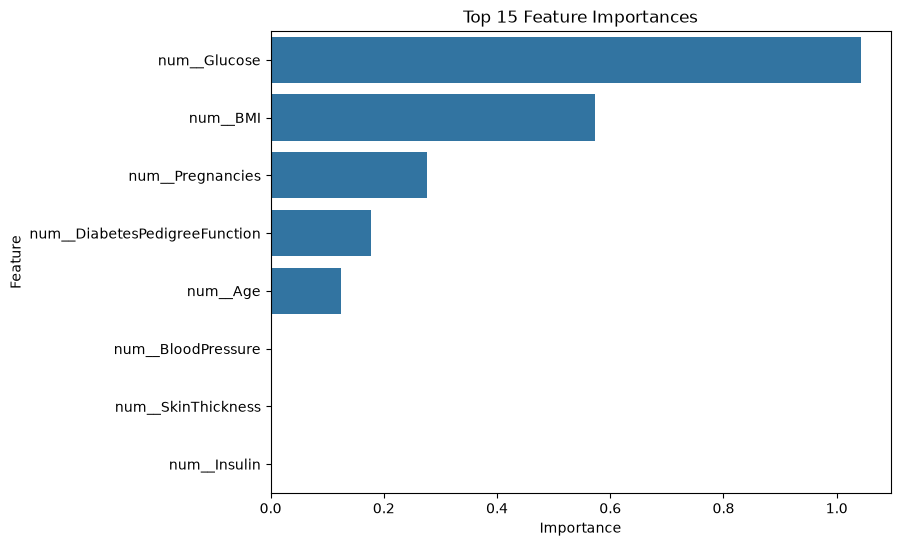

In [48]:
plt.figure(figsize=(8, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df.head(10)
)

plt.title('Top 15 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [49]:
sample = X_test.iloc[[0]]

prediction = best_model.predict(sample)[0]
probability = best_model.predict_proba(sample)[0]

print("Sample Data:")
display(sample)

print("Actual value:", y_test.iloc[0])
print("Predicted value:", prediction)

print("Probability of Non-Diabetic:", probability[0])
print("Probability of Diabetic:", probability[1])

if prediction == 1:
    print("Final Prediction: Diabetic")
else:
    print("Final Prediction: Non-Diabetic")

Sample Data:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
44,7,159.0,64.0,NaN,NaN,27.4,0.294,40


Actual value: 0
Predicted value: 1
Probability of Non-Diabetic: 0.27249035540011646
Probability of Diabetic: 0.7275096445998835
Final Prediction: Diabetic


In [50]:
print(type(best_model))

<class 'sklearn.pipeline.Pipeline'>


In [51]:
import joblib
import json

# Save the trained pipeline (same as before)
joblib.dump(best_model, 'diabetes_pipeline.joblib')

# Save the column config so the Streamlit app knows exactly what to expect
column_config = {
    'feature_cols': list(X_train.columns),   # captures exact column names + order used in training
    'target_col': 'Outcome'                   # change this if your target column has a different name
}

with open('diabetes_column_config.json', 'w') as f:
    json.dump(column_config, f, indent=2)

print("Model saved as 'diabetes_pipeline.joblib'")
print("Column config saved as 'diabetes_column_config.json'")
print(f"\nModel expects these columns in this exact order:")
print(column_config['feature_cols'])

Model saved as 'diabetes_pipeline.joblib'
Column config saved as 'diabetes_column_config.json'

Model expects these columns in this exact order:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
